In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [3]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import os

base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"
os.listdir(base_path)


['PNEUMONIA', 'NORMAL']

In [5]:
normal_count = len(os.listdir(os.path.join(base_path, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(base_path, 'PNEUMONIA')))

print("Normal Images:", normal_count)
print("Pneumonia Images:", pneumonia_count)

Normal Images: 1341
Pneumonia Images: 3875


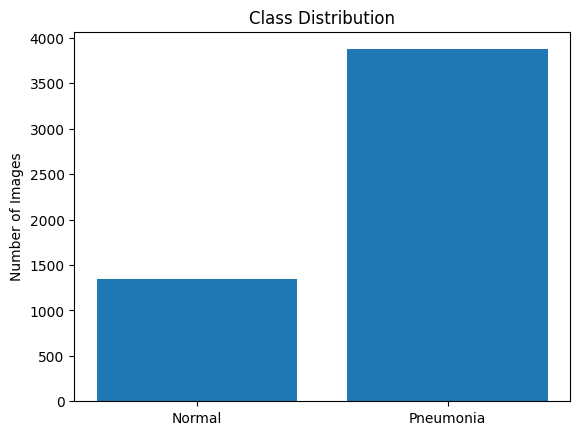

In [6]:
plt.bar(['Normal', 'Pneumonia'], [normal_count, pneumonia_count])
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.show()

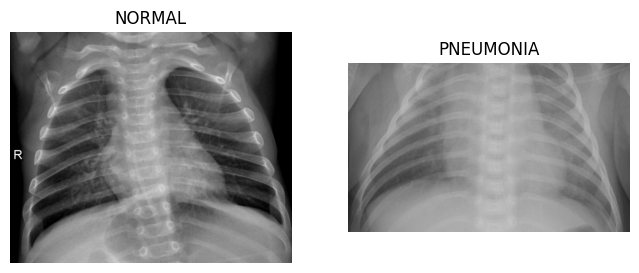

In [7]:
from PIL import Image
import random

normal_images = os.listdir(os.path.join(base_path, 'NORMAL'))
pneumonia_images = os.listdir(os.path.join(base_path, 'PNEUMONIA'))

# Pick random images
normal_img = random.choice(normal_images)
pneumonia_img = random.choice(pneumonia_images)

img1 = Image.open(os.path.join(base_path, 'NORMAL', normal_img))
img2 = Image.open(os.path.join(base_path, 'PNEUMONIA', pneumonia_img))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.title('NORMAL')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
plt.title('PNEUMONIA')
plt.axis('off')
plt.show()

In [8]:
sizes = []

for img in normal_images[:100]:  # sample check
    img_path = os.path.join(base_path, 'NORMAL', img)
    img = Image.open(img_path)
    sizes.append(img.size)

set(sizes)

{(1014, 846),
 (1160, 904),
 (1164, 1021),
 (1168, 960),
 (1186, 940),
 (1198, 897),
 (1218, 1032),
 (1222, 970),
 (1272, 1048),
 (1276, 1059),
 (1296, 1052),
 (1296, 1200),
 (1304, 1028),
 (1314, 1171),
 (1330, 1133),
 (1336, 1128),
 (1338, 1102),
 (1342, 1059),
 (1346, 1044),
 (1354, 1078),
 (1384, 1090),
 (1384, 1121),
 (1400, 1260),
 (1402, 1105),
 (1410, 970),
 (1410, 1106),
 (1412, 1198),
 (1422, 1128),
 (1454, 1071),
 (1462, 1140),
 (1472, 978),
 (1488, 1017),
 (1500, 1194),
 (1500, 1249),
 (1500, 1294),
 (1508, 1052),
 (1510, 1136),
 (1512, 1302),
 (1542, 1461),
 (1546, 1399),
 (1554, 1151),
 (1554, 1271),
 (1566, 1225),
 (1566, 1465),
 (1574, 1129),
 (1576, 1272),
 (1580, 1410),
 (1588, 1217),
 (1600, 1380),
 (1620, 1151),
 (1620, 1340),
 (1630, 1353),
 (1632, 1206),
 (1634, 1210),
 (1636, 1329),
 (1654, 1259),
 (1654, 1441),
 (1666, 1252),
 (1670, 1344),
 (1676, 1391),
 (1690, 1334),
 (1690, 1383),
 (1692, 1221),
 (1696, 1298),
 (1700, 1271),
 (1704, 1341),
 (1704, 1487),
 (1

In [9]:
img1.mode


'L'

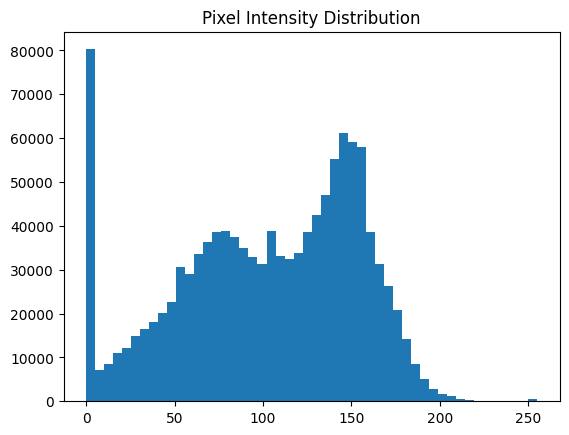

In [10]:


img_array = np.array(img1)
plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

Observations:

The dataset consists of chest X‑ray images categorized into NORMAL and PNEUMONIA.
The dataset shows class imbalance with higher pneumonia samples.
Images are grayscale with varying resolutions.
Data augmentation will be required to improve model generalization.

In [11]:
for split in ['train', 'val', 'test']:
    path = f"/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/{split}"
    normal = len(os.listdir(os.path.join(path, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    print(split, "→ NORMAL:", normal, "| PNEUMONIA:", pneumonia)


train → NORMAL: 1341 | PNEUMONIA: 3875
val → NORMAL: 8 | PNEUMONIA: 8
test → NORMAL: 234 | PNEUMONIA: 390


 **Challenges Identified:**


* Class imbalance (Pneumonia > Normal)
* Similar visual patterns across classes
* Variable image sizes
* Risk of overfitting


In [12]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


2026-05-19 11:50:50.491310: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779191450.682237      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779191450.738617      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779191451.218424      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779191451.218483      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779191451.218486      57 computation_placer.cc:177] computation placer alr

In [13]:
train_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"
val_dir   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val"
test_dir  = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test"

In [14]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode='grayscale',
    class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode='grayscale',
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    color_mode='grayscale',
    class_mode='binary',
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-19 11:51:12.469699: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.optimizers import Adam

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.7521 - loss: 0.5295 - val_accuracy: 0.6250 - val_loss: 0.8516
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9009 - loss: 0.2447 - val_accuracy: 0.6875 - val_loss: 0.7663
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9223 - loss: 0.2089 - val_accuracy: 0.6875 - val_loss: 0.7875
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.9263 - loss: 0.1827 - val_accuracy: 0.6875 - val_loss: 0.8801
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9294 - loss: 0.1668 - val_accuracy: 0.7500 - val_loss: 0.4556
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9381 - loss: 0.1591 - val_accuracy: 0.7500 - val_loss: 0.6947
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9347 - loss: 0.1683 - val_accuracy: 0.6875 - val_loss: 0.7367
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9411 - loss: 0.1574 - val_accu

In [19]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 451ms/step - accuracy: 0.7326 - loss: 0.7619
Test Accuracy: 0.8365384340286255


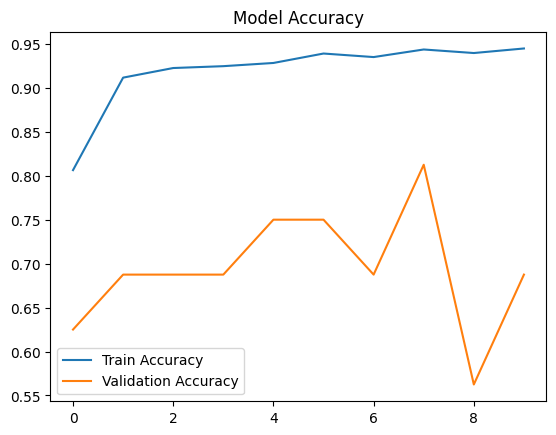

In [20]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()